# Lab 5

Description of lab:

Probability distributions: uniform, normal, binomial, poisson.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from cycler import cycler

plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams["axes.labelsize"]= 12
plt.rcParams["figure.facecolor"] = "#f2f2f2"
#plt.rcParams['figure.savefig.dpi'] = 100
plt.rcParams['savefig.edgecolor'] = "#f2f2f2"
plt.rcParams['savefig.facecolor'] ="#f2f2f2"
plt.rcParams["figure.figsize"] = [16,10]
plt.rcParams['savefig.bbox'] = "tight"
plt.rcParams['font.size'] = 14
greens = ['#66c2a4','#41ae76','#238b45','#006d2c','#00441b']
multi =['#66c2a4','#1f78b4','#a6cee3','#b2df8a','#33a02c','#fb9a99','#e31a1c','#fdbf6f']
plt.rcParams["axes.prop_cycle"] = cycler(color=multi)

Making some fake data:

In [24]:
num = 1000

error = np.random.uniform(-1, 1, num)

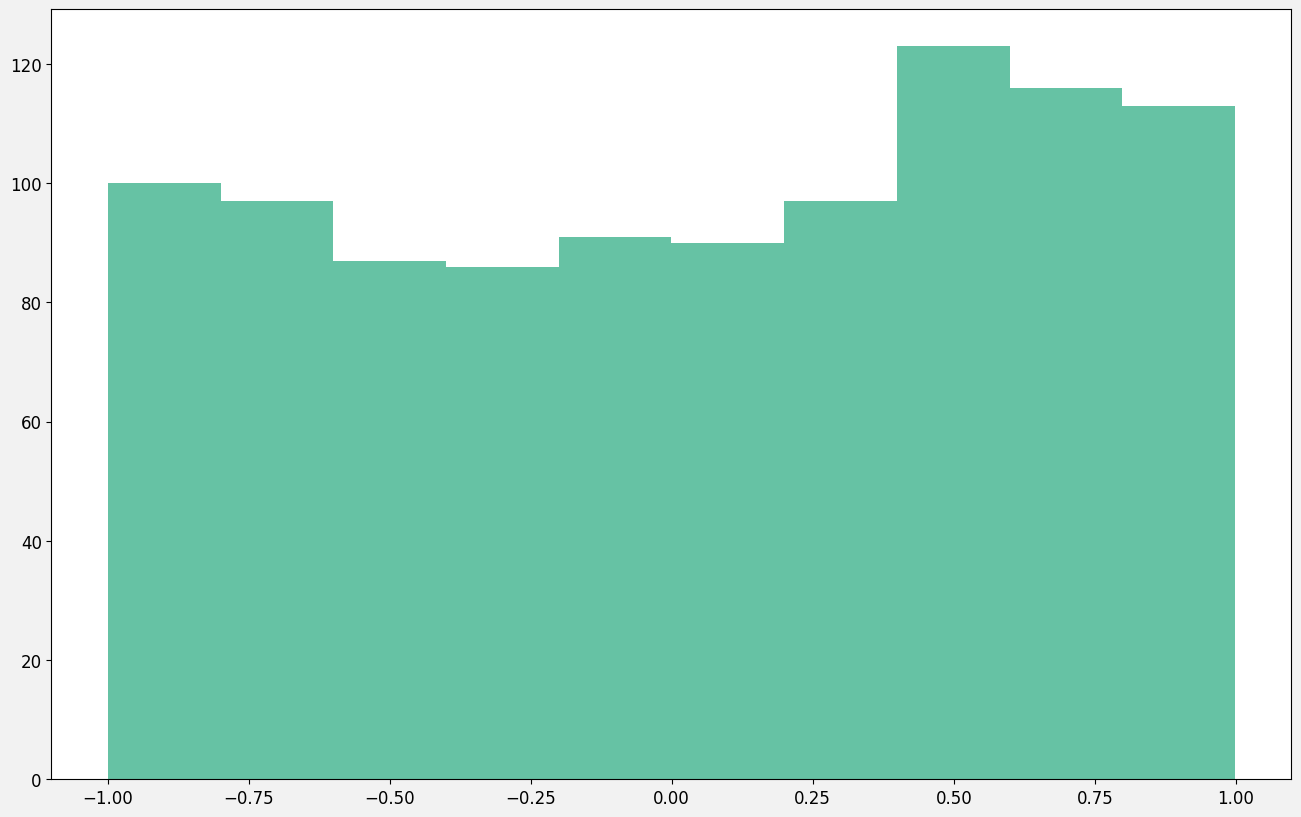

In [25]:
plt.hist(error)
plt.show()

In [26]:
# Mean:
mean_error = error.sum() / error.size
mean_error = np.mean(error)
mean_error = error.mean()

# Variance:
var_error = ((error - mean_error) ** 2).mean()
var_error = np.var(error)
var_error = error.var()

# Standard deviation:
std_error = np.sqrt(var_error)
std_error = error.std()

In [27]:
print('Mean: ', mean_error)
print('Variance: ', var_error)
print('Standard deviation: ', std_error)

Mean:  0.044068502272031136
Variance:  0.34694100326303523
Standard deviation:  0.5890169804539044


In [32]:
n = 1000
m = 10000
meanValues = []

for i in range(m):
    uniformData = np.random.uniform(-1, 1, n)
    meanValues.append(uniformData.mean())

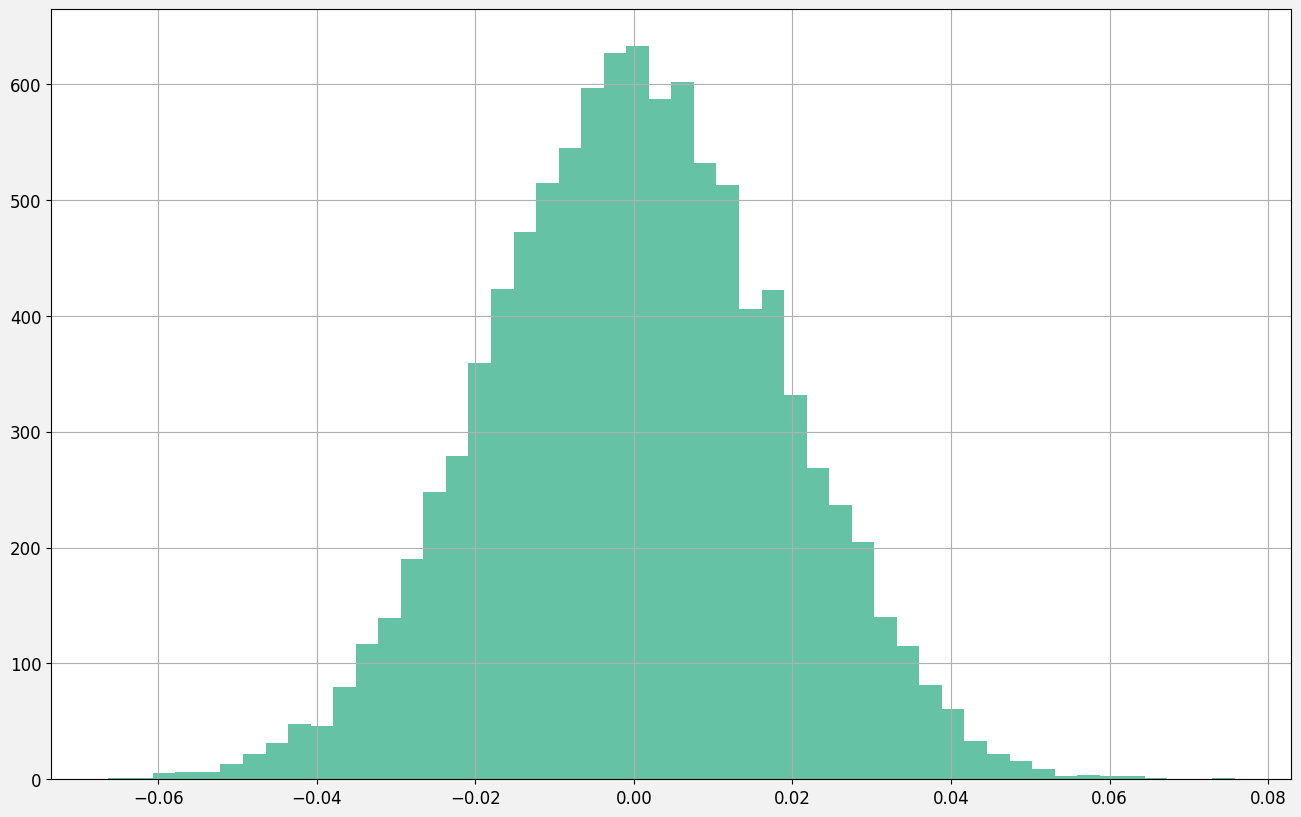

In [33]:
pd.Series(meanValues).hist(bins = 50)
plt.show()

**Central limit theorem:** If you draw from a random variable, from any distribution, take the mean or sum of those draws and repeat several times, the distribution wil be normal. Any process that can be seen to be a summation or averaging of smaller steps will tend to be normally distributed.

In [34]:
# Simulating normal distribution directly:
X = np.random.normal(10, 1, 1000)

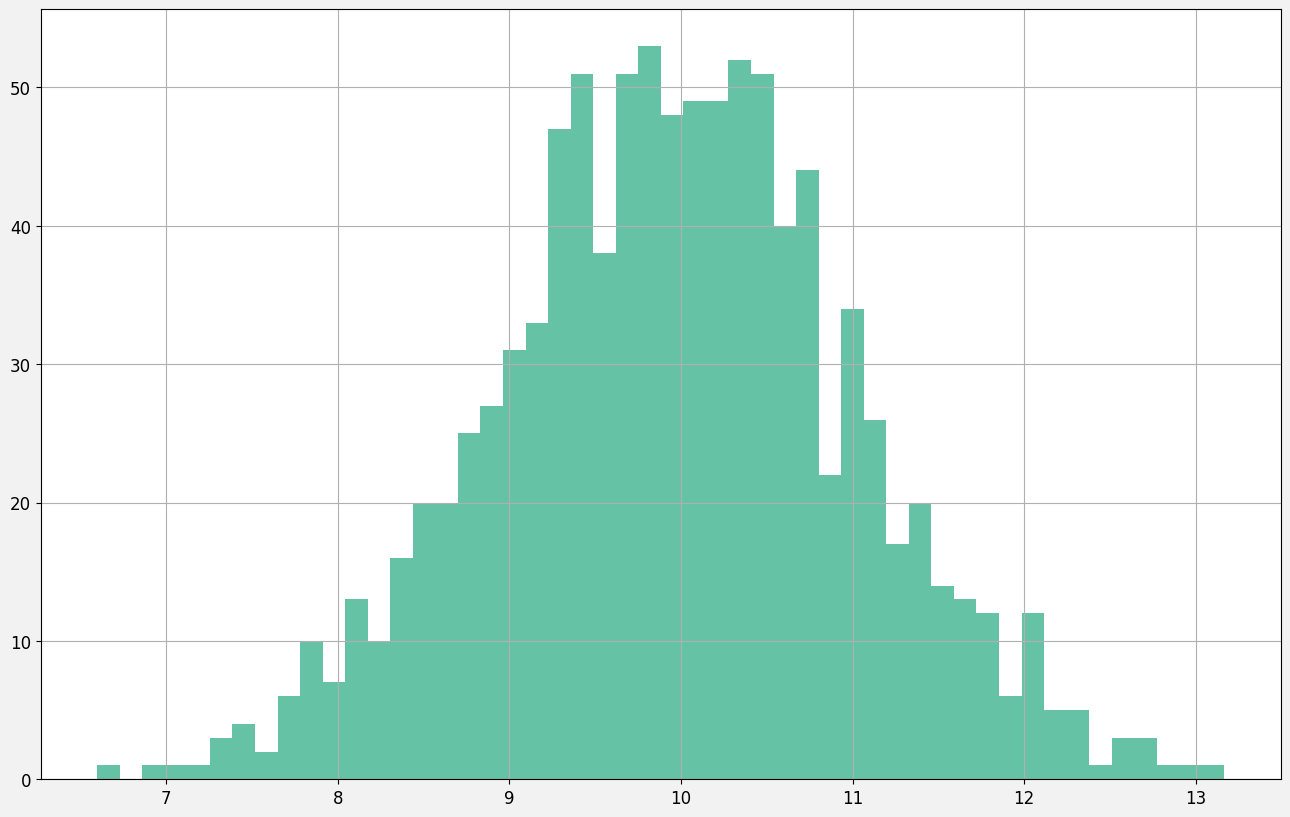

In [36]:
X = pd.Series(X)
X.hist(bins = 50)
plt.show()

In [37]:
print(X.mean(), X.std())

9.958721633713202 1.0451130906566086


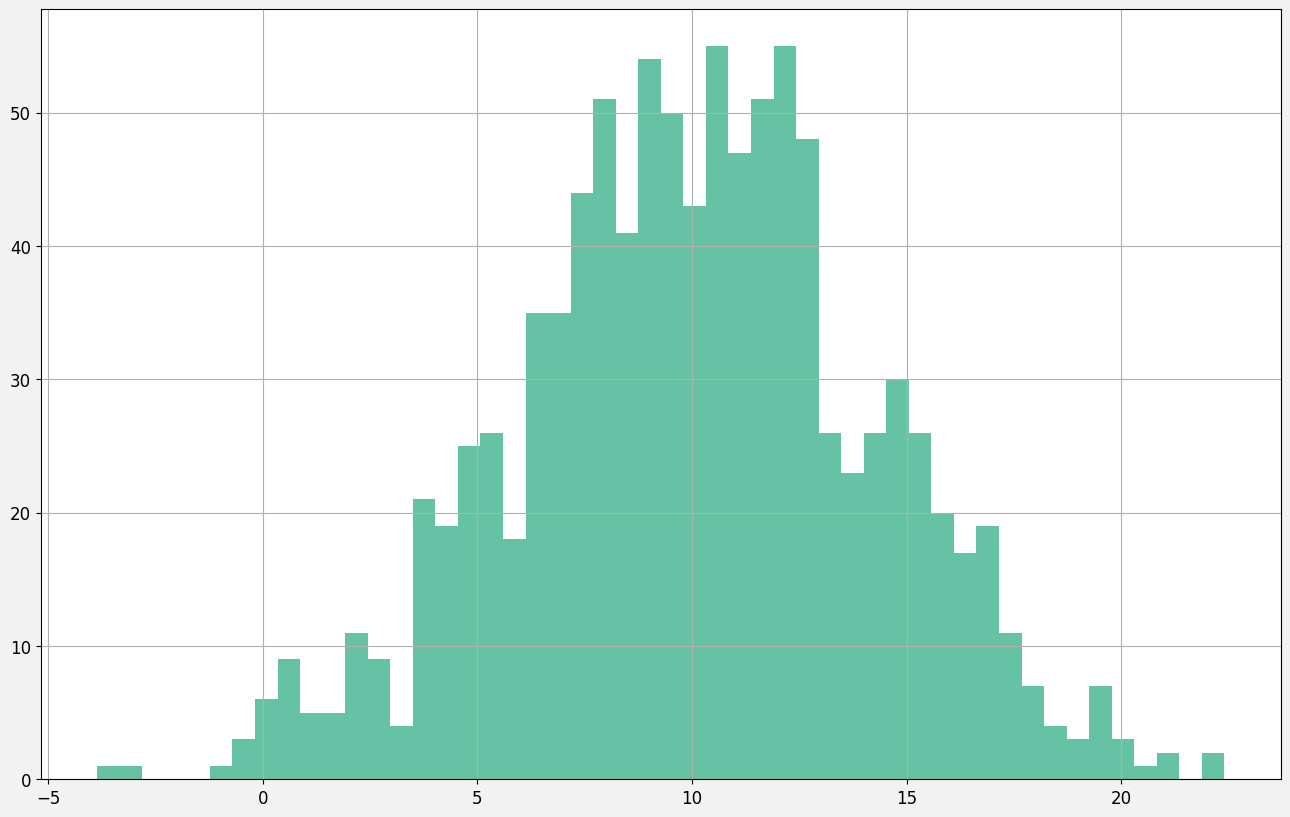

In [40]:
X2 = pd.Series(np.random.normal(10, 4, 1000))
X2.hist(bins = 50)
plt.show()

In [42]:
# What percentage is within one standard deviation of the mean (should be around 68%):
X2[(X2 > 6) & (X2 < 14)].count() / 1000

0.663

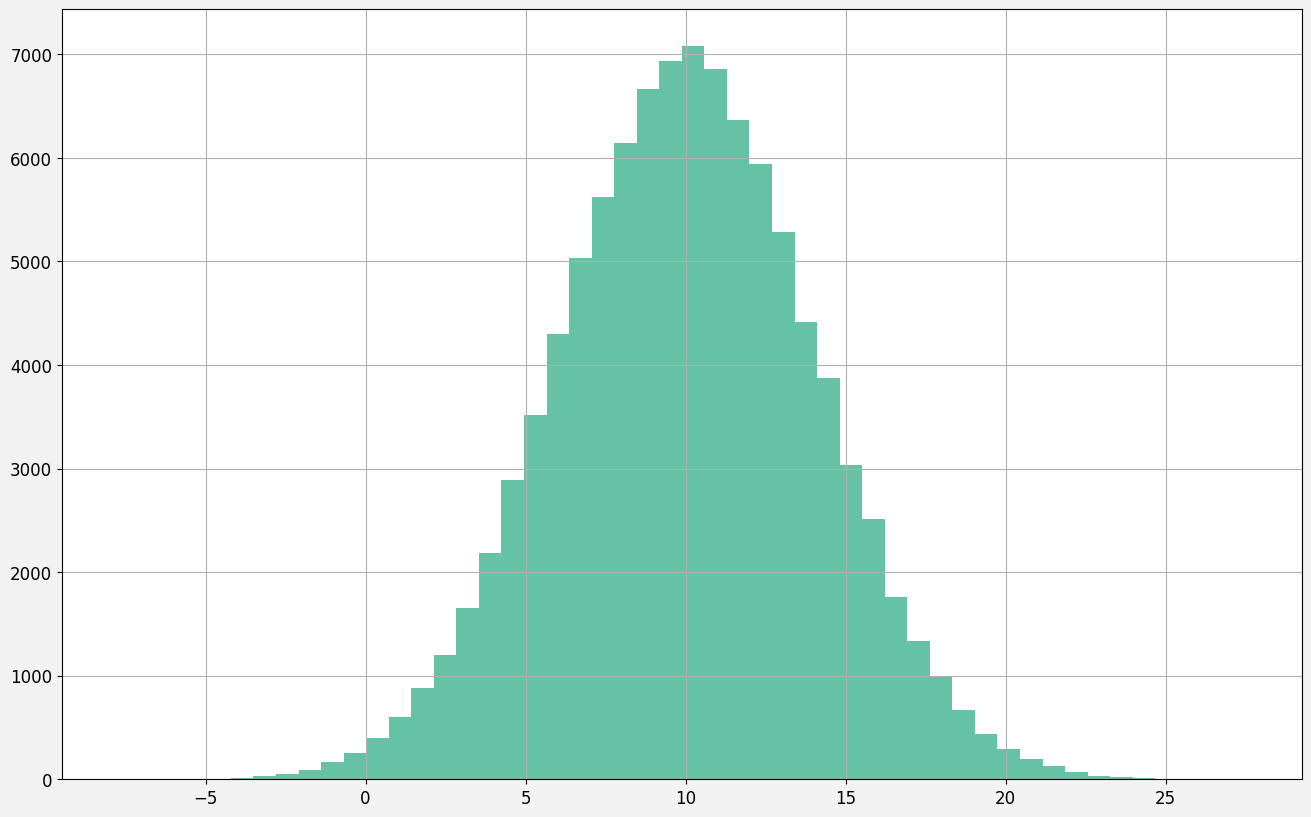

In [44]:
N = 100000
X2 = pd.Series(np.random.normal(10, 4, N))
X2.hist(bins = 50)
plt.show()

In [46]:
# What percentage is within two standard deviations of the mean (should be around 95%):
X2[(X2 > 2) & (X2 < 18)].count() / N

0.95349

### Linear transformation of normal distributions

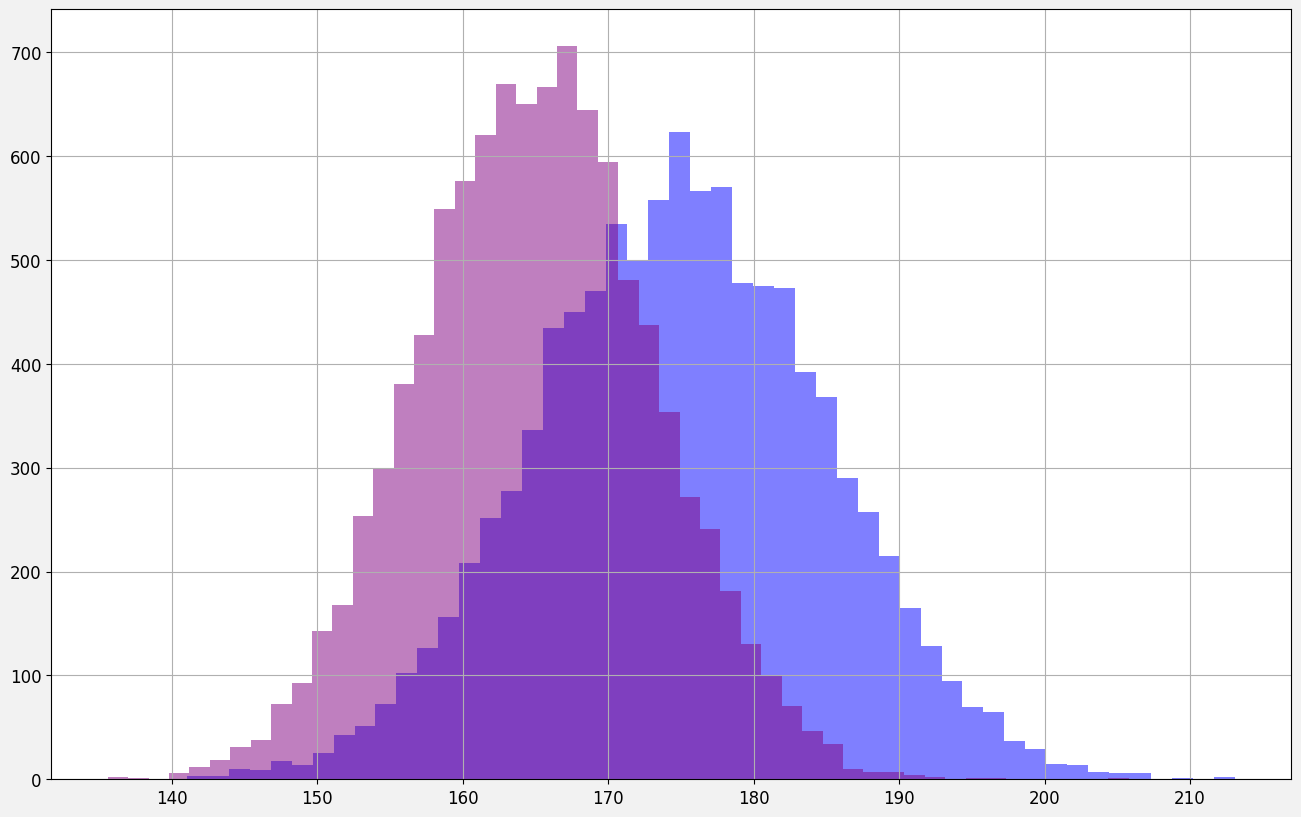

In [50]:
N = 10000
XY = pd.Series(np.random.normal(175, 10, N))
XX = pd.Series(np.random.normal(165, 8, N))

fig, ax = plt.subplots()
XY.hist(ax = ax, color = 'blue', alpha = .5, bins = 50)
XX.hist(ax = ax, color = 'purple', alpha = .5, bins = 50)
plt.show()

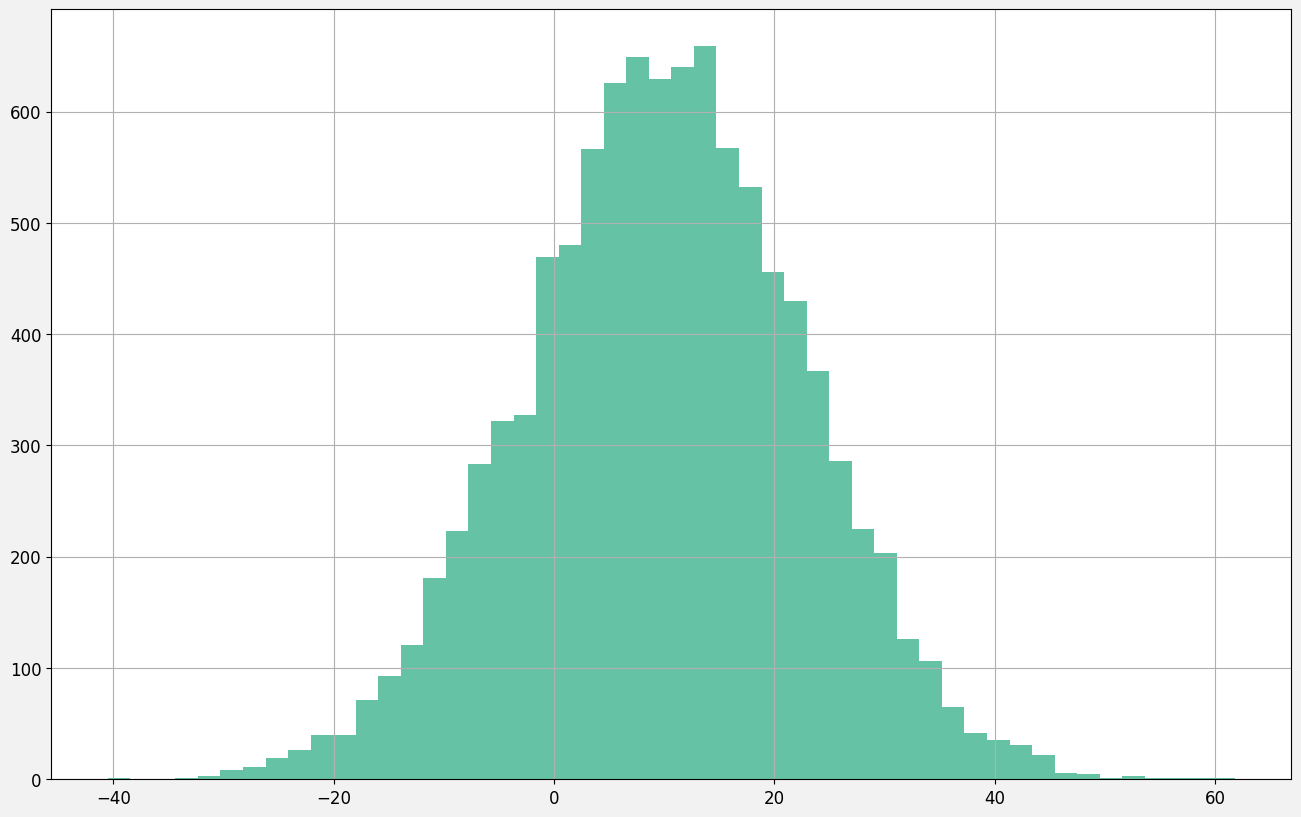

Mean: 9.939413955056112  STD: 12.692721507466239


In [51]:
difference = XY - XX
difference.hist(bins = 50)
plt.show()

print('Mean:', difference.mean(), ' STD:', difference.std())

In [52]:
print('True STD: ', np.sqrt(10**2 + 8**2))

True STD:  12.806248474865697


### Correlated random variables

In [53]:
X = pd.Series(np.random.normal(10, 4, 10000))
Y = pd.Series(2 + 0.2*X + np.random.normal(0, 2, 10000))

In [54]:
print(X.mean(), Y.mean())
print(X.std(), Y.std())

10.009534441035733 3.9905965928904634
3.986595395995696 2.160041405420542


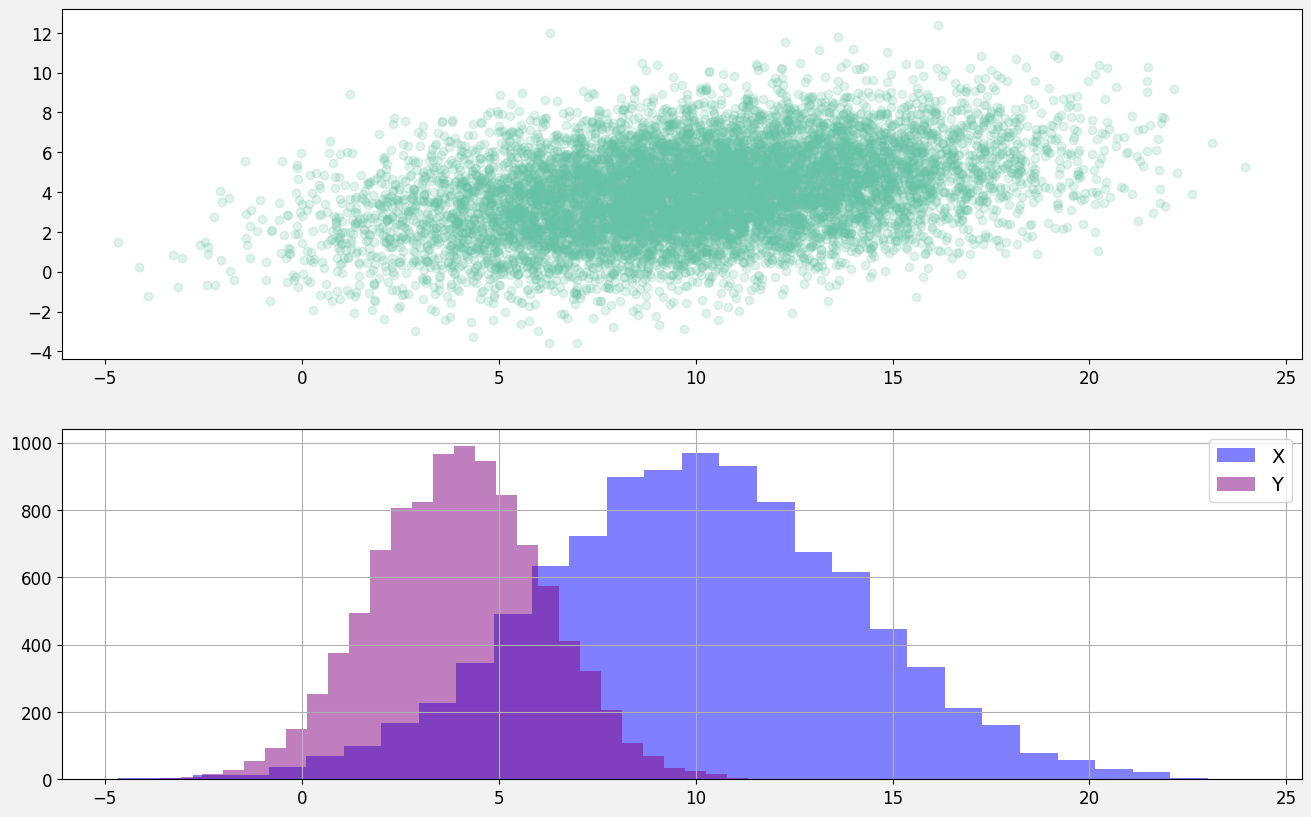

In [58]:
fig, ax = plt.subplots(2)
ax[0].scatter(X, Y, alpha = .2)
X.hist(bins = 30, ax = ax[1], alpha = .5, label = 'X', color = 'blue')
Y.hist(bins = 30, ax = ax[1], alpha = .5, label = 'Y', color = 'purple')
plt.legend()
plt.show()

Correlation coefficient: $\rho_{XY} = \frac{E((X - \mu_{X})(Y - \mu_{Y}))}{\sigma_{X} \cdot \sigma_{Y}}$

In [59]:
corr = np.mean((X - X.mean()) * (Y - Y.mean())) / (X.std() * Y.std())
print('Correlation coefficient: ', corr)

Correlation coefficient:  0.3655152080315234


In [60]:
np.corrcoef(X, Y)

array([[1.        , 0.36555176],
       [0.36555176, 1.        ]])

### Adding two correlated random variables

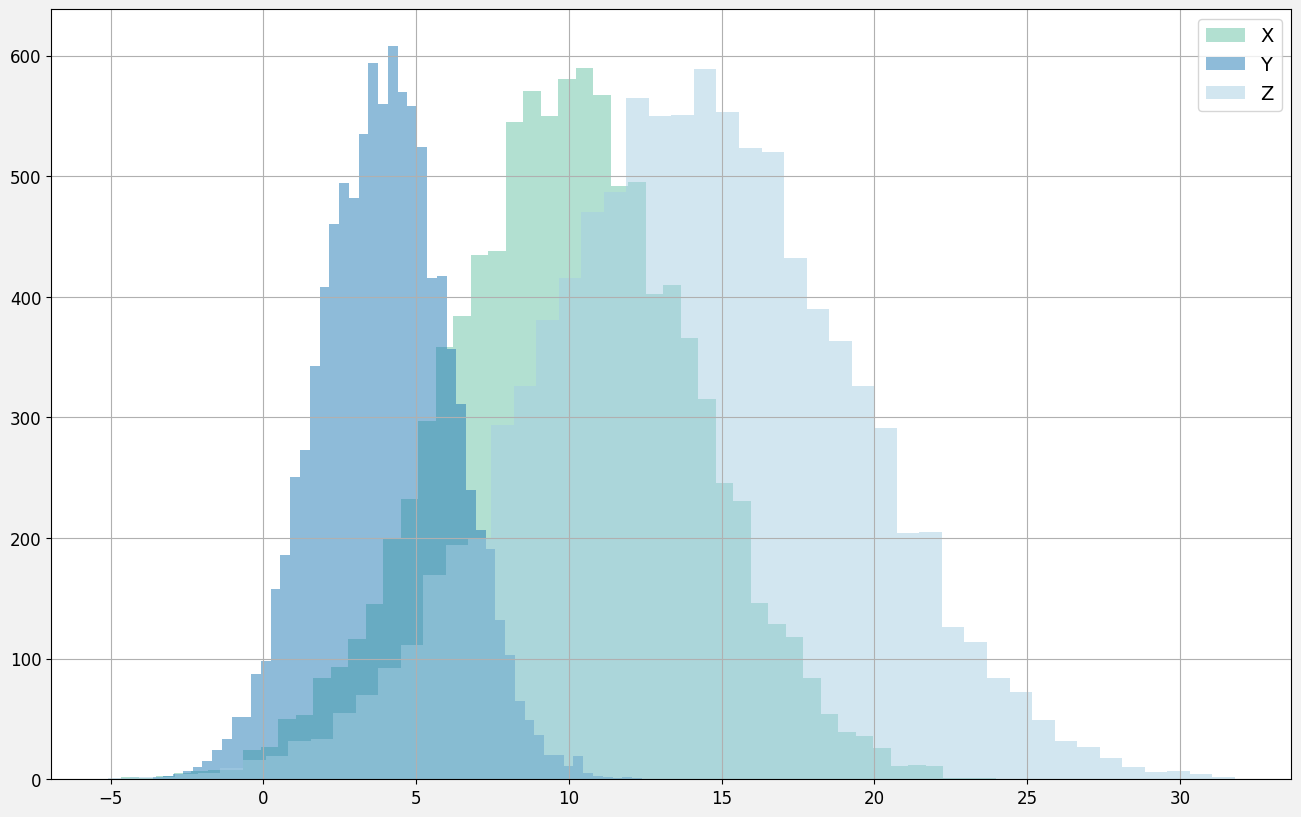

In [61]:
Z = X + Y

fig, ax = plt.subplots()
X.hist(bins = 50, ax = ax, alpha = .5, label = 'X')
Y.hist(bins = 50, ax = ax, alpha = .5, label = 'Y')
Z.hist(bins = 50, ax = ax, alpha = .5, label = 'Z')
plt.legend()
plt.show()

In [62]:
print('Z: mean:', Z.mean(), ' STD:', Z.std())

Z: mean: 14.000131033926195  STD: 5.182123941253861


Mean is the sum of the mean for X and Y, std is: $\sigma_{Z} = \sqrt{\sigma_{X}^{2} + \sigma_{Y}^{2} + 2\rho\sigma_{X}\sigma_{Y}}$

In [63]:
print('True STD: ', np.sqrt(4 ** 2 + 2 ** 2 + 2 * .37 * 4 * 2))

True STD:  5.091168824543142


### Other distributions

In [67]:
# Binomial distribution:
n = 100
p = 0.3
size = 10000

numPass = pd.Series(np.random.binomial(n, p, size))
numPass

0       30
1       38
2       36
3       41
4       23
        ..
9995    33
9996    32
9997    35
9998    32
9999    30
Length: 10000, dtype: int32

In [68]:
print(numPass.mean(), numPass.std())

30.0142 4.576209406184656


In [69]:
print('True mean:', n * p, ' True STD:', np.sqrt(n * p * (1 - p)))

True mean: 30.0  True STD: 4.58257569495584


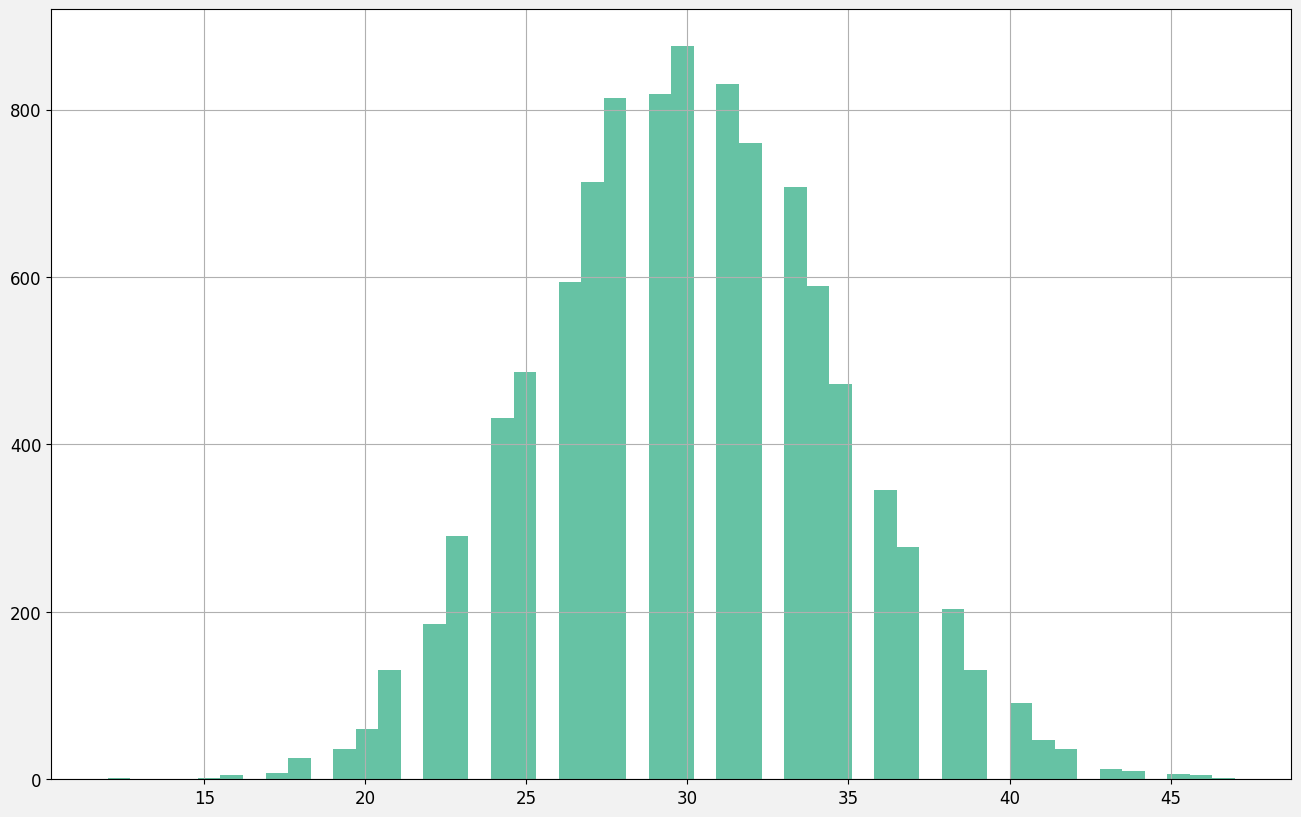

In [70]:
numPass.hist(bins = 50)
plt.show()

### Count data and poisson distribution

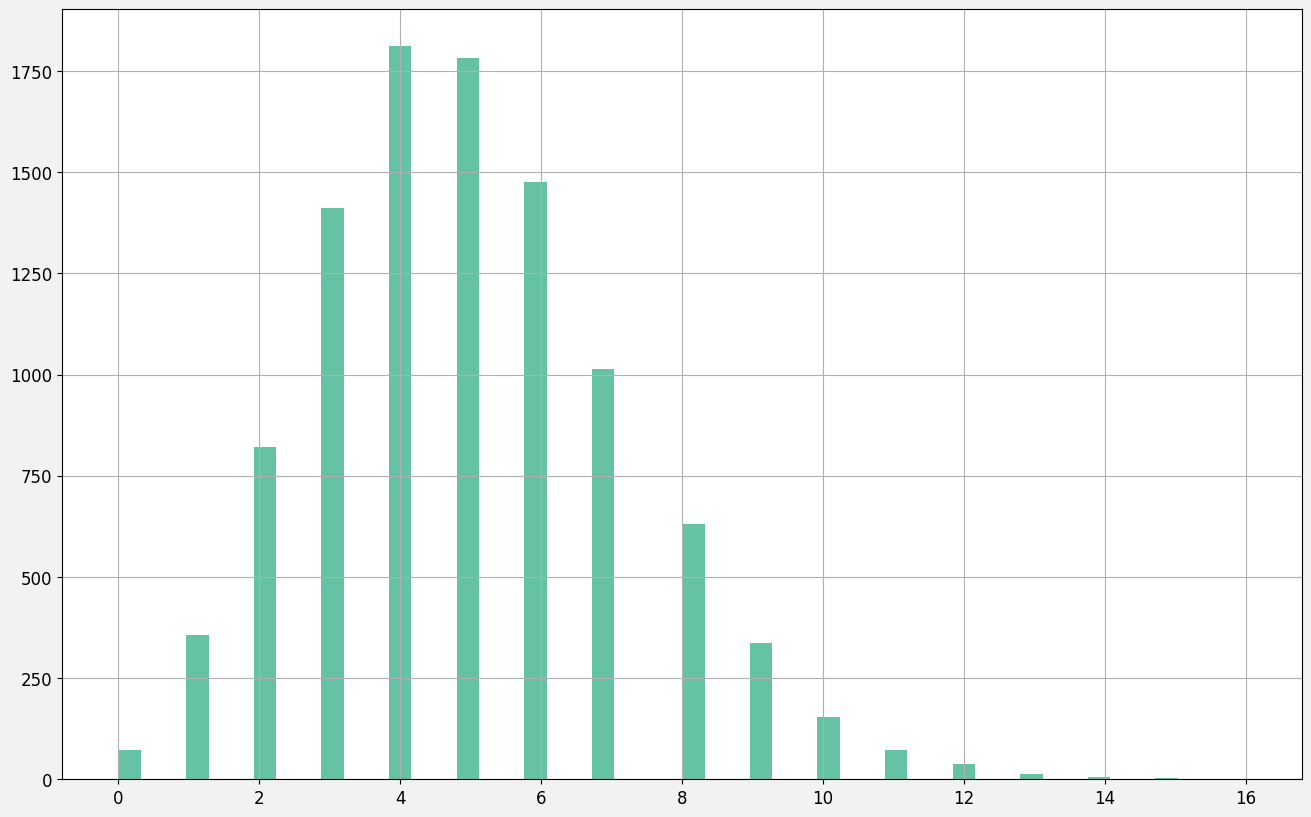

In [71]:
customersPerHour = pd.Series(np.random.poisson(5, 10000))

customersPerHour.hist(bins = 50)
plt.show()

Notice: All positive, poisson has to be positive, also loger positive tail (positive skew)

In [72]:
print(customersPerHour.mean(), customersPerHour.var())

4.9516 4.899347374737474
